In [1]:
import pykep as pk
import numpy as np
import json
import pickle as pkl

from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pyplot as plt
%matplotlib notebook

In [2]:
import cascade as csc
from copy import deepcopy
from tqdm.notebook import tqdm
import heyoka as hy

In [3]:
with open("data/debris_simulation_ic.pk", "rb") as file:
    r_ic,v_ic,reentry_radius,to_satcat,satcat,debris = pkl.load(file)

In [4]:
with open("data/best_fit_density.pk", "rb") as file:
    best_x = pkl.load(file)

In [5]:
# We need to create an array containing all B*
BSTARS = []
for idx in to_satcat:
    BSTARS.append(float(satcat[idx]["BSTAR"]))
# We put the BSTAR in SI units
BSTARS = np.array(BSTARS) / pk.EARTH_RADIUS
# We remove negative BSTARS setting the value to zero in those occasions
BSTARS[BSTARS<0] = 0.

In [6]:
# This little helper returns the heyoka expression for the density using
# the results from the data interpolation
def compute_density(h, best_x):
    """
    Returns the heyoka expression for the atmosheric density in kg.m^3. 
    Input is the altitude in m. 
    (when we fitted km were used here we change as to allow better expressions)
    """
    p1 = np.array(best_x[:4])
    p2 = np.array(best_x[4:8]) / 1000
    p3 = np.array(best_x[8:]) * 1000
    retval = 0.
    for alpha,beta, gamma in zip(p1,p2, p3):
        retval += alpha*hy.exp(-(h-gamma)*beta)
    return retval

In [7]:
# Dynamical variables.
x,y,z,vx,vy,vz = hy.make_vars("x","y","z","vx","vy","vz")

# Constants.
GMe = pk.MU_EARTH
C20 = -4.84165371736e-4
C22 = 2.43914352398e-6
S22 = -1.40016683654e-6
Re = pk.EARTH_RADIUS

# Create Keplerian dynamics.
dyn = csc.dynamics.kepler(mu = GMe)

In [8]:
# Add the J2 terms.
magr2 = x**2+y**2+z**2
J2term1 = GMe*(Re**2)*np.sqrt(5)*C20/(2*magr2**(1./2))
J2term2 = 3/(magr2**2)
J2term3 = 15*(z**2)/(magr2**3)
fJ2x = J2term1*x*(J2term2 - J2term3)
fJ2y = J2term1*y*(J2term2 - J2term3)
fJ2z = J2term1*z*(3*J2term2 - J2term3)
dyn[3] = (dyn[3][0], dyn[3][1] + fJ2x)
dyn[4] = (dyn[4][0], dyn[4][1] + fJ2y)
dyn[5] = (dyn[5][0], dyn[5][1] + fJ2z)

In [9]:
# Add the Earth's C22 and S22 terms.
# This value represents the rotation of the Earth fixed system at t0
theta_g = (np.pi/180)*280.4606 #[rad] 
# This value represents the magnitude of the Earth rotation
nu_e = (np.pi/180)*(4.178074622024230e-3) #[rad/sec]

X =  x*hy.cos(theta_g + nu_e*hy.time) + y*hy.sin(theta_g + nu_e*hy.time)
Y = -x*hy.sin(theta_g + nu_e*hy.time) + y*hy.cos(theta_g + nu_e*hy.time)
Z = z

C22term1 = 5*GMe*(Re**2)*np.sqrt(15)*C22/(2*magr2**(7./2))
C22term2 = GMe*(Re**2)*np.sqrt(15)*C22/(magr2**(5./2))
fC22X = C22term1*X*(Y**2 - X**2) + C22term2*X
fC22Y = C22term1*Y*(Y**2 - X**2) - C22term2*Y
fC22Z = C22term1*Z*(Y**2 - X**2)

S22term1 = 5*GMe*(Re**2)*np.sqrt(15)*S22/(magr2**(7./2))
S22term2 = GMe*(Re**2)*np.sqrt(15)*S22/(magr2**(5./2))
fS22X = -S22term1*(X**2)*Y + S22term2*Y
fS22Y = -S22term1*X*(Y**2) + S22term2*X
fS22Z = -S22term1*X*Y*Z

fC22x = fC22X*hy.cos(theta_g + nu_e*hy.time) - fC22Y*hy.sin(theta_g + nu_e*hy.time)
fC22y = fC22X*hy.sin(theta_g + nu_e*hy.time) + fC22Y*hy.cos(theta_g + nu_e*hy.time)
fC22z = fC22Z

fS22x = fS22X*hy.cos(theta_g + nu_e*hy.time) - fS22Y*hy.sin(theta_g + nu_e*hy.time)
fS22y = fS22X*hy.sin(theta_g + nu_e*hy.time) + fS22Y*hy.cos(theta_g + nu_e*hy.time)
fS22z = fS22Z

dyn[3] = (dyn[3][0], dyn[3][1] + fC22x + fS22x)
dyn[4] = (dyn[4][0], dyn[4][1] + fC22y + fS22y)
dyn[5] = (dyn[5][0], dyn[5][1] + fC22z + fS22z)

In [10]:
# Adds the drag force.
magv2 = vx**2+vy**2+vz**2
magv = hy.sqrt(magv2)
# Here we consider a spherical Earth ... would be easy to account for the oblateness effect.
altitude = (hy.sqrt(magr2) - Re)
density = compute_density(altitude, best_x)
ref_density = 0.1570 / Re
fdrag = density / ref_density * hy.par[0] * magv
fdragx = - fdrag * vx
fdragy = - fdrag * vy
fdragz = - fdrag * vz
dyn[3] = (dyn[3][0], dyn[3][1] + fdragx)
dyn[4] = (dyn[4][0], dyn[4][1] + fdragy)
dyn[5] = (dyn[5][0], dyn[5][1] + fdragz)

In [11]:
csc.set_logger_level_trace()

In [12]:
def remove_particle(idx, r_ic, v_ic, BSTARS,to_satcat, reentry_radius):
    r_ic = np.delete(r_ic, idx, axis=0)
    BSTARS = np.delete(BSTARS, idx, axis=0)
    v_ic = np.delete(v_ic, idx, axis=0)
    to_satcat = np.delete(to_satcat, idx, axis=0)
    reentry_radius = np.delete(reentry_radius, idx, axis=0)
    return r_ic, v_ic, BSTARS, to_satcat, reentry_radius

In [13]:
# Before starting we need to remove all particles inside our playing field
min_radius = pk.EARTH_RADIUS+150000.
inside_the_radius = np.where(np.linalg.norm(r_ic,axis=1) < min_radius)[0]
print("Removing orbiting objects:")
for idx in inside_the_radius:
    print(satcat[to_satcat[idx]]["OBJECT_NAME"], "-", satcat[to_satcat[idx]]["OBJECT_ID"])
r_ic, v_ic, BSTARS,to_satcat, reentry_radius = remove_particle(inside_the_radius, r_ic, v_ic, BSTARS,to_satcat, reentry_radius)

Removing orbiting objects:
LEMUR 2 ROCKETJONAH - 2017-071E
ISARA - 2017-071P
FREGAT DEB - 2011-037EM
STARLINK-1684 - 2020-070H
COSMOS 1408 DEB - 1982-092Z
COSMOS 1408 DEB - 1982-092AK
COSMOS 1408 DEB - 1982-092ES
COSMOS 1408 DEB - 1982-092FK
COSMOS 1408 DEB - 1982-092FY
COSMOS 1408 DEB - 1982-092GU
COSMOS 1408 DEB - 1982-092NA
COSMOS 1408 DEB - 1982-092PV
COSMOS 1408 DEB - 1982-092PW
COSMOS 1408 DEB - 1982-092RM
COSMOS 1408 DEB - 1982-092ACG
COSMOS 1408 DEB - 1982-092AQC
COSMOS 1408 DEB - 1982-092ARK
COSMOS 1408 DEB - 1982-092AXA
COSMOS 1408 DEB - 1982-092AXD
COSMOS 1408 DEB - 1982-092BDB
COSMOS 1408 DEB - 1982-092BFU
COSMOS 1408 DEB - 1982-092BKD


In [14]:
# Prepare the data in the shape expected by the simulation object.
ic_state = np.hstack([r_ic, v_ic, reentry_radius.reshape((r_ic.shape[0], 1))])
pars = BSTARS.reshape((r_ic.shape[0], 1))

# Uncommen these lines to save the txt files to be used in the cpp simulations
#np.savetxt("test_ic_19647.txt", ic_state.reshape((-1, 1))
#np.savetxt("test_par_19647.txt", pars)

In [15]:
sim = csc.sim(ic_state,0.23 * 806.81,dyn=dyn,pars=pars, reentry_radius=min_radius)

[2026-03-04 09:51:29.108] [cascade] [trace] Integrators setup time: 8.940716274s
[2026-03-04 09:51:29.846] [cascade] [trace] JIT functions setup time: 0.733970209s


In [16]:
# new_state  =deepcopy(ic_state)
# new_pars  =deepcopy(pars)
# new_to_satcat  =deepcopy(to_satcat)

rng = np.random


In [17]:
import time

In [ ]:
test_sizes = [10, 100, 500, 1000, 2500, 5000, 10000, 15000, 19647]

sim_duration = 1 * pk.DAY2SEC  # 1 day in seconds
dt = 60.0                       # 60s time step
bench_results = []

print(f"Starting Benchmark: {sim_duration}s duration, {dt}s step.")
print(f"{'Objects':<10} | {'Wall Time (s)':<15} | {'Speed (steps/s)':<15}")
print("-" * 55)

for N in test_sizes:
    # 1. Slice data
    current_ic = ic_state[:N]
    current_pars = pars[:N]
    
    # 2. Initialize simulation
    sim = csc.sim(current_ic, dt, dyn=dyn, pars=current_pars, reentry_radius=min_radius)
    
    # 3. Setup Progress Bar and Timing
    start_t = time.perf_counter()
    pbar = tqdm(total=sim_duration, desc=f"Size: {N}", leave=True)
    
    last_sim_time = 0.0

    while sim.time < sim_duration:
        oc = sim.step()
        
        # Calculate actual time delta for pbar (handles interrupts correctly)
        time_delta = sim.time - last_sim_time
        pbar.update(time_delta)
        last_sim_time = sim.time
        
        if oc == csc.outcome.collision:
            pi, pj = sim.interrupt_info
            # Removed print statement to avoid slowing down benchmark
            for idx in [pi, pj]:
                a = rng.uniform(1.02*Re, 1.3*Re)
                e = rng.uniform(0, 0.02)
                inc = rng.uniform(0, 0.05)
                om = rng.uniform(0, 2*np.pi)
                Om = rng.uniform(0, 2*np.pi)
                nu = rng.uniform(0, 2*np.pi)
                size = rng.uniform(0.01, 0.1)

                r, v = pk.par2ic([a, e, inc, om, Om, nu], pk.MU_EARTH)

                sim.state[idx,0:3] = r
                sim.state[idx,3:6] = v
                sim.state[idx,6] = size

        elif oc == csc.outcome.reentry:
            pi = sim.interrupt_info

            t_current = sim.time
            new_state = np.delete(sim.state, pi, axis=0)
            new_pars = np.delete(sim.pars, pi, axis=0)
            sim = csc.sim(new_state, dt, dyn=dyn, pars=new_pars, reentry_radius=min_radius)
            
            sim.time = t_current
            
    pbar.close()
    end_t = time.perf_counter()
    
    total_t = end_t - start_t
    bench_results.append(total_t)
    
    # 4. Results Reporting
    steps_per_sec = (sim_duration / dt) / total_t
    print(f"{N:<10} | {total_t:<15.2f} | {steps_per_sec:<15.2f}")

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt

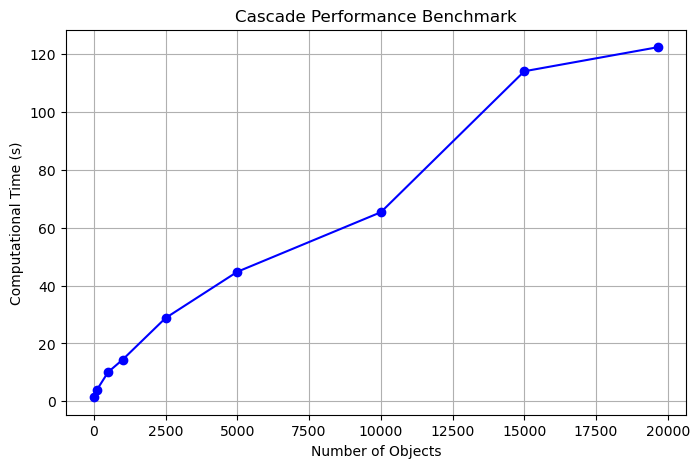

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(test_sizes, bench_results, marker='o', linestyle='-', color='blue')
plt.xlabel('Number of Objects')
plt.ylabel('Computational Time (s)')
plt.title('Cascade Performance Benchmark')
plt.grid(True)
plt.show()

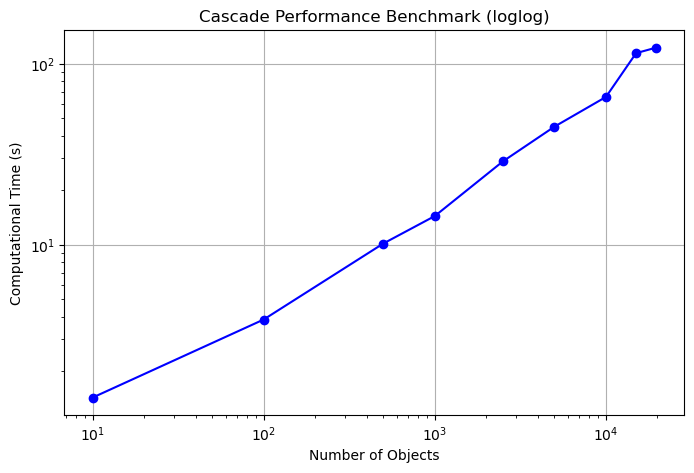

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(test_sizes, bench_results, marker='o', linestyle='-', color='blue')
plt.xlabel('Number of Objects')
plt.ylabel('Computational Time (s)')
plt.title('Cascade Performance Benchmark (loglog)')
plt.grid(True)
plt.xscale('log')
plt.yscale('log')
plt.show()

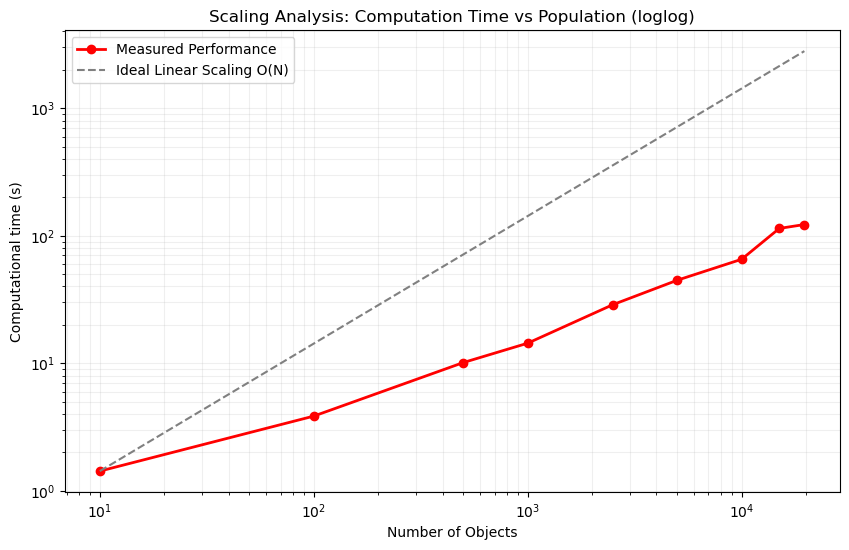

In [30]:
fig = plt.figure(figsize=(10, 6))
plt.loglog(test_sizes, bench_results, 'o-r', lw=2, label='Measured Performance')

theoretical_n = [bench_results[0] * (n / test_sizes[0]) for n in test_sizes]
plt.loglog(test_sizes, theoretical_n, '--', color='gray', label='Ideal Linear Scaling O(N)')

plt.title('Scaling Analysis: Computation Time vs Population (loglog)')
plt.xlabel('Number of Objects')
plt.ylabel('Computational time (s)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

In [ ]:
test_sizes = [10, 100, 500, 1000, 2500, 5000, 10000, 15000, 19647]

sim_duration = 1 * pk.DAY2SEC  # 1 day in seconds
dt = 30.0                        # 30s time step
bench_results = []

print(f"Starting Benchmark: {sim_duration}s duration, {dt}s step.")
print(f"{'Objects':<10} | {'Wall Time (s)':<15} | {'Speed (steps/s)':<15}")
print("-" * 55)

for N in test_sizes:
    # 1. Slice data
    current_ic = ic_state[:N]
    current_pars = pars[:N]
    
    # 2. Initialize simulation
    sim = csc.sim(current_ic, dt, dyn=dyn, pars=current_pars, reentry_radius=min_radius)
    
    # 3. Setup Progress Bar and Timing
    start_t = time.perf_counter()
    pbar = tqdm(total=sim_duration, desc=f"Size: {N}", leave=True)
    
    last_sim_time = 0.0

    while sim.time < sim_duration:
        oc = sim.step()
        
        # Calculate actual time delta for pbar (handles interrupts correctly)
        time_delta = sim.time - last_sim_time
        pbar.update(time_delta)
        last_sim_time = sim.time
        
        if oc == csc.outcome.collision:
            pi, pj = sim.interrupt_info
            # Removed print statement to avoid slowing down benchmark
            for idx in [pi, pj]:
                a = rng.uniform(1.02*Re, 1.3*Re)
                e = rng.uniform(0, 0.02)
                inc = rng.uniform(0, 0.05)
                om = rng.uniform(0, 2*np.pi)
                Om = rng.uniform(0, 2*np.pi)
                nu = rng.uniform(0, 2*np.pi)
                size = rng.uniform(0.01, 0.1)

                r, v = pk.par2ic([a, e, inc, om, Om, nu], pk.MU_EARTH)

                sim.state[idx,0:3] = r
                sim.state[idx,3:6] = v
                sim.state[idx,6] = size

        elif oc == csc.outcome.reentry:
            pi = sim.interrupt_info

            t_current = sim.time
            new_state = np.delete(sim.state, pi, axis=0)
            new_pars = np.delete(sim.pars, pi, axis=0)
            sim = csc.sim(new_state, dt, dyn=dyn, pars=new_pars, reentry_radius=min_radius)
            
            sim.time = t_current
            
    pbar.close()
    end_t = time.perf_counter()
    
    total_t = end_t - start_t
    bench_results.append(total_t)
    
    # 4. Results Reporting
    steps_per_sec = (sim_duration / dt) / total_t
    print(f"{N:<10} | {total_t:<15.2f} | {steps_per_sec:<15.2f}")

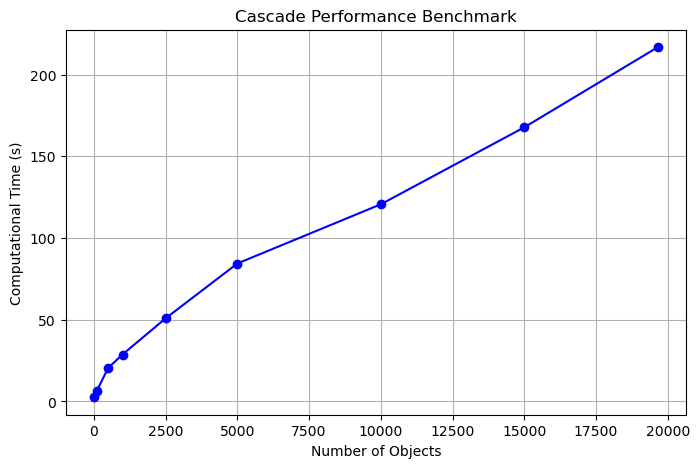

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(test_sizes, bench_results, marker='o', linestyle='-', color='blue')
plt.xlabel('Number of Objects')
plt.ylabel('Computational Time (s)')
plt.title('Cascade Performance Benchmark')
plt.grid(True)
plt.show()

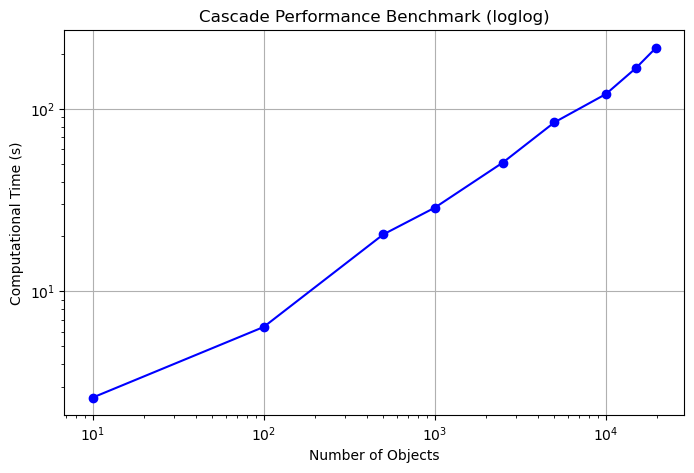

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(test_sizes, bench_results, marker='o', linestyle='-', color='blue')
plt.xlabel('Number of Objects')
plt.ylabel('Computational Time (s)')
plt.title('Cascade Performance Benchmark (loglog)')
plt.grid(True)
plt.xscale('log')
plt.yscale('log')
plt.show()

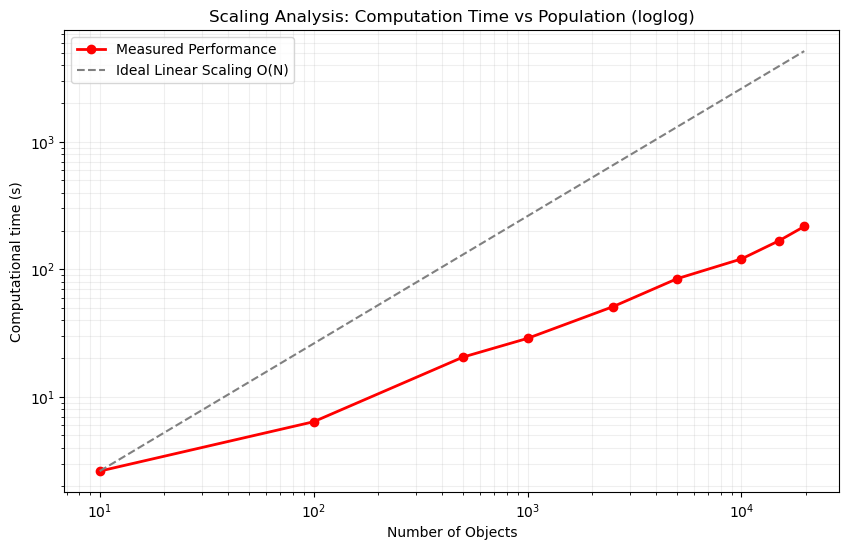

In [35]:
fig = plt.figure(figsize=(10, 6))
plt.loglog(test_sizes, bench_results, 'o-r', lw=2, label='Measured Performance')

theoretical_n = [bench_results[0] * (n / test_sizes[0]) for n in test_sizes]
plt.loglog(test_sizes, theoretical_n, '--', color='gray', label='Ideal Linear Scaling O(N)')

plt.title('Scaling Analysis: Computation Time vs Population (loglog)')
plt.xlabel('Number of Objects')
plt.ylabel('Computational time (s)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()